## Exercises 2


### Exercise 2.1.
Wine Quality Data Set: "data/wines.csv"
source: https://archive.ics.uci.edu/ml/datasets/wine+quality
The file contains data on samples of white and red Portuguese wine 
Vinho Verde. 
Various physico-chemical characteristics of individual samples
are available as well as wine quality scores on a point scale (0-10) 
made by specialists.

estimate the linear regression model with the quality 
evaluation as the dependent variable,
treating the explained variable as quantitative.

In [17]:
import pandas as pd
wine = pd.read_csv(r"D:\FPT\DAP391M\Assignment\SP26-AI1904-DAP391m\lab_part_2\01 - Linear and logistic regression\data\wines.csv")
pd.set_option('display.max_columns', 50)
wine.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,type,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,red,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,red,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,red,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,red,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,red,5


In [18]:
Tp = {'red': 1, 'white': 2}
wine['type'] = wine.type.map(Tp)
print(wine['type'].unique())

[1 2]


In [19]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth', None)
print(wine.corr('spearman'))

                      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  free_sulfur_dioxide  total_sulfur_dioxide   density        pH  sulphates   alcohol      type   quality
fixed_acidity              1.000000          0.200272     0.270568       -0.032254   0.355964            -0.259914             -0.233259  0.434056 -0.250044   0.220145 -0.110650 -0.423682 -0.098154
volatile_acidity           0.200272          1.000000    -0.295129       -0.064384   0.415896            -0.365673             -0.343534  0.261437  0.194876   0.255042 -0.023924 -0.599149 -0.257806
citric_acid                0.270568         -0.295129     1.000000        0.074920  -0.074084             0.122058              0.159355  0.065690 -0.285905   0.036898  0.019653  0.161228  0.105711
residual_sugar            -0.032254         -0.064384     0.074920        1.000000  -0.035800             0.387750              0.454886  0.526664 -0.229344  -0.138157 -0.329218  0.256540 -0.016891
chlorides 

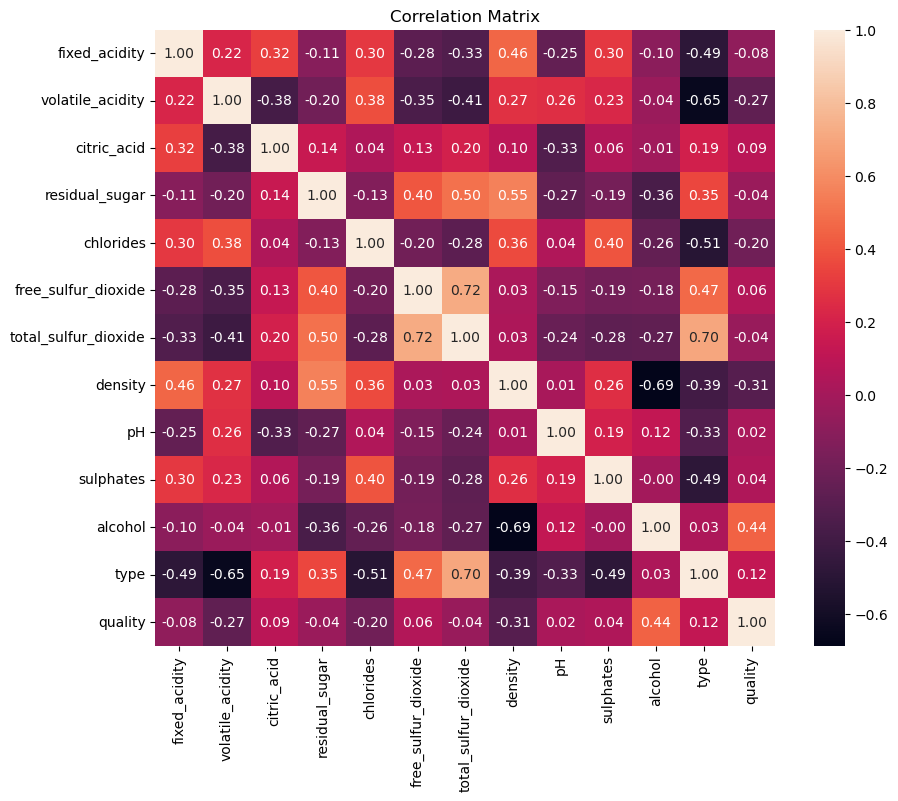

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(wine.corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [25]:
x = wine.drop(columns=['quality'])
print(x.shape[0])

6497


In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
x = wine.drop(columns=['quality'])
vif = pd.DataFrame()
vif['feature'] = x.columns
vif['VIF'] = [variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
print(vif.sort_values(by='VIF', ascending=False))


                 feature          VIF
7                density  1344.987489
8                     pH   662.567217
10               alcohol   111.897077
11                  type    88.978659
0          fixed_acidity    71.616994
6   total_sulfur_dioxide    20.516517
9              sulphates    20.104994
1       volatile_acidity    11.261938
2            citric_acid     9.388566
5    free_sulfur_dioxide     8.719112
4              chlorides     5.850895
3         residual_sugar     3.576225


Có thể thấy các feature của wine dataset bị đa cộng tuyến rất mạnh, nên cần phải thử loại bỏ bớt một vài cột để giảm thiểu

In [31]:
y = wine.drop(columns=['pH','sulphates','alcohol','quality','free_sulfur_dioxide','total_sulfur_dioxide','residual_sugar'])
vif1 = pd.DataFrame()
vif1['feature'] = y.columns
vif1['VIF'] = [variance_inflation_factor(y.values,i) for i in range(y.shape[1])]
print(vif1.sort_values(by='VIF', ascending=False))

            feature         VIF
4           density  164.004078
0     fixed_acidity   55.540346
5              type   45.108966
1  volatile_acidity   10.597842
2       citric_acid    9.016236
3         chlorides    5.056760


In [32]:
import sklearn
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(y, wine['quality'], test_size=0.2, random_state=42)
model = sklearn.linear_model.LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
predictions = model.predict(x_test)
print(predictions, y_test.values)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

[6.14083074 5.55939086 5.93406406 ... 6.43744912 5.35685672 5.65824342] [8 5 7 ... 7 6 7]
Mean Squared Error: 0.6101201142776891
R^2 Score: 0.17389099885165937


### Exercise 2.2.
Titanic passengers data – 1310 observations and 15 variables:
```
passenger_id – Unique passenger id
pclass – Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
survived – Survival (0 = No, 1 = Yes)
name – Name and SUrname
sex – Sex (0 = Male, 1 = Female)
age – Age in years
sibsp – of siblings / spouses aboard the Titanic
parch – of parents / children aboard the Titanic
ticket – Ticket number
fare – Passenger fare
cabin – Cabin number
embarked – Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)
boat – Lifeboat (if survived)
body – Body number (if did not survive and body was recovered)
home.dest – Home/Destination
```

estimate logistic regression model that can be used to 
explain the probability of survival (survived = 1).

lets load medical_care data after transformations
applied last week 


In [4]:
titanic = pd.read_csv(r"D:\FPT\DAP391M\Assignment\SP26-AI1904-DAP391m\lab_part_2\01 - Linear and logistic regression\data\titanic.csv")
pd.set_option('display.max_columns', 50)
titanic.head()

,passenger_id,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,1,"Allen, Miss. Elisabeth Walton",1,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,2,1,1,"Allison, Master. Hudson Trevor",0,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,3,1,0,"Allison, Miss. Helen Loraine",1,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,4,1,0,"Allison, Mr. Hudson Joshua Creighton",0,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,5,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [6]:
print(titanic['survived'].value_counts())
print(titanic['survived'].isnull().sum())

survived
0    809
1    500
Name: count, dtype: int64
0


In [35]:
x = titanic.drop(columns=['survived'])
pd.set_option('display.max_rows', 20)
#print(x.dtypes)
print(x.isnull().sum())
#print(x.describe(include='all'))

passenger_id       0
pclass             0
name               0
sex                0
age              263
sibsp              0
parch              0
ticket             0
fare               1
cabin           1014
embarked           2
boat             823
body            1188
home.dest        564
dtype: int64


In [36]:
print(titanic['embarked'].value_counts())

embarked
S    914
C    270
Q    123
Name: count, dtype: int64


In [72]:
z = titanic.copy()
z['boat'] = z['boat'].fillna('0')
z['body'] = z['body'].fillna(0)
z['age'] = z['age'].fillna(z['age'].median())
z['fare'] = z['fare'].fillna(z['fare'].median())
z['embarked'] = z['embarked'].fillna('S')

In [58]:

num_cols = z.select_dtypes(include=['int64','float64']).columns
cat_cols = z.select_dtypes(include=['object']).columns

In [55]:
print(list(num_cols))

['passenger_id', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'body']


Target encoding đơn giản cho cột text

In [59]:
target = "survived"

df_tmp = z.copy()
for col in cat_cols:
    df_tmp[col+'_te'] = df_tmp.groupby(col)[target].transform('mean')

print(df_tmp.head())
cols_for_corr = list(num_cols) + [c+"_te" for c in cat_cols]
corr = df_tmp[cols_for_corr].corr()

   passenger_id  pclass  survived                                             name  sex      age  sibsp  parch  ticket      fare    cabin embarked boat   body                        home.dest  name_te  ticket_te  cabin_te  embarked_te   boat_te  home.dest_te
0             1       1         1                    Allen, Miss. Elisabeth Walton    1  29.0000      0      0   24160  211.3375       B5        S    2    0.0                     St Louis, MO      1.0        1.0      1.00     0.334061  1.000000          1.00
1             2       1         1                   Allison, Master. Hudson Trevor    0   0.9167      1      2  113781  151.5500  C22 C26        S   11    0.0  Montreal, PQ / Chesterville, ON      1.0        0.5      0.25     0.334061  1.000000          0.25
2             3       1         0                     Allison, Miss. Helen Loraine    1   2.0000      1      2  113781  151.5500  C22 C26        S    0    0.0  Montreal, PQ / Chesterville, ON      0.0        0.5      0.25  

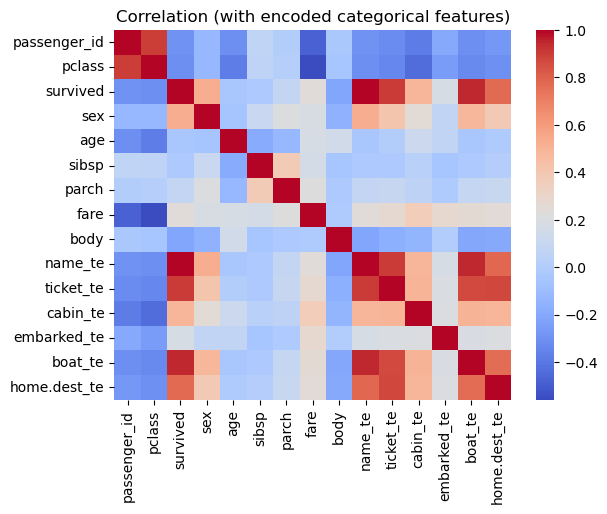

In [60]:

sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation (with encoded categorical features)")
plt.show()


In [80]:
#z = z.drop(columns=['passenger_id','survived','body','name','ticket','home.dest','boat'])
#z['cabin_deck'] = z['cabin'].fillna('Missing').astype(str).str[0]
#freq = z['cabin_deck'].value_counts(normalize=True)
#rare = freq[freq < 0.02].index

#z['cabin_deck'] = z['cabin_deck'].replace(rare, 'Rare')
#z = pd.get_dummies(z, columns=['cabin_deck'], drop_first=True)
#z = z.drop(columns=['cabin'])
z = pd.get_dummies(z, columns=['embarked'], drop_first=True)
print(z.head())


   pclass  sex      age  sibsp  parch      fare  cabin_deck_C  cabin_deck_D  cabin_deck_E  cabin_deck_M  cabin_deck_Rare  cabin_deck_C  cabin_deck_D  cabin_deck_E  cabin_deck_M  cabin_deck_Rare  embarked_Q  embarked_S
0       1    1  29.0000      0      0  211.3375         False         False         False         False            False         False         False         False         False            False       False        True
1       1    0   0.9167      1      2  151.5500          True         False         False         False            False          True         False         False         False            False       False        True
2       1    1   2.0000      1      2  151.5500          True         False         False         False            False          True         False         False         False            False       False        True
3       1    0  30.0000      1      2  151.5500          True         False         False         False            False        

In [81]:

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(z, titanic['survived'], test_size=0.2, random_state=42)
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [82]:
from sklearn.metrics import mean_squared_error, r2_score
predictions = model.predict(x_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)
print(predictions, y_test.values)

Mean Squared Error: 0.21755725190839695
R^2 Score: 0.12111581920903991
[0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 1 1 1 0 0 0 1 0 0 1
 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0
 0 0 0 1 0 1 0 0 0 0 1 0 0 1 1 1 1 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 1 0 1 1 0
 0 0 1 1 0 0 0 0 1 0 0 1 1 0 0 0 0 1 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0
 1 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 0 1 0 0 1 0
 1 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 1 0 0 0 1 1
 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 1 1
 1 0 1] [0 1 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 0 0 1 1 1 1 1 1 1 0 0 1
 0 1 0 1 1 1 0 0 0 0 1 1 1 1 0 1 1 0 0 0 1 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1
 1 0 0 0 0 1 0 0 0 1 1 0 0 1 1 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0
 1 0 1 1 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0
 0 1 1 1 1 1 0 1 1 0 0 0 0 1 1 0 1 0 0 1 0 1 1 1 1 1 1 0 1 0 1 0 1 1 0 1 0
 1 1 1 1 0 0 0 0 1 0 

### Exercise 2.3.
Wine Quality Data Set: "data/wines.csv"

estimate the multinomial logistic regression model with 
the quality evaluation as the dependent variable,
treating the explained variable as qualitative.